## **Machine Learning Aplicado a las Finanzas** 🚀
### **Sesión 11: Crédito/Fraude — Desbalance, Calibración y Estabilidad**

Andrés C. Medina Sanhueza

Senior Data Scientist Engineer

anmedinas@gmail.com

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
    brier_score_loss, confusion_matrix, classification_report, f1_score
)
from sklearn.frozen import FrozenEstimator
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import warnings

sns.set_style("dark")
warnings.filterwarnings("ignore")
np.random.seed(42)
pd.set_option("display.float_format", "{:.4f}".format)

## 🎯 **`Motivación: Crédito y Fraude no son el Mismo Problema de Desbalance`**

En la sesión 2 (*MLCreditScoring*) usamos el dataset `Bankloan` para introducir *pitfalls* generales de ML en finanzas. Esta sesión vuelve sobre el mismo tipo de problema — clasificación binaria de riesgo — pero enfocada en tres dificultades que aparecen cuando la clase de interés (default, fraude) es minoritaria:

1. **Desbalance de clases**, que rompe la métrica de *accuracy* y, si es severo, puede colapsar un clasificador a predecir siempre la clase mayoritaria sin que el error de entrenamiento lo delate.
2. **Calibración**, porque un score no es solo para rankear (¿quién es más riesgoso que quién?) sino frecuentemente para tomar una decisión con un umbral de negocio o alimentar un cálculo de pérdida esperada (`PD × LGD × EAD`) — y ahí *el valor numérico de la probabilidad importa*, no solo el orden.
3. **Estabilidad**, retomando el PSI de la sesión 10 pero aplicado ahora al *score del modelo* y a *subpoblaciones* (segmentos demográficos), un requisito típico de gobernanza en modelos de crédito regulados.

Trabajamos con dos datasets de distinta severidad de desbalance a propósito:

| | Crédito (`Bankloan`, sesión 2) | Fraude (sintético) |
|---|---|---|
| Tasa de la clase positiva | ~36% (desbalance moderado) | ~2% (desbalance severo) |
| Naturaleza | Datos reales, transversal (sin fecha) | Simulado (`make_classification`) — no existe un dataset de fraude real incluido en el curso |
| Uso en esta sesión | Calibración y estabilidad por segmento | Comparación de estrategias de resampling |

Usar un dataset real de desbalance moderado y uno sintético de desbalance severo permite mostrar ambos extremos sin depender de una descarga externa no reproducible.

## 💳 **`Sección A — Crédito: Desbalance Moderado y el Problema del Umbral 0.5`**

Recuperamos `Bankloan` (sesión 2): 1466 solicitudes de crédito, target `Default` (1 = incumplió). A diferencia de los datos de las sesiones 3-10, este dataset es **transversal** (no tiene una dimensión temporal explícita) — por lo tanto usamos `train_test_split` estratificado en vez de walk-forward: la estratificación garantiza que la proporción de defaults sea la misma en train/val/test, algo que un split aleatorio simple podría no respetar por azar cuando la clase minoritaria es chica.

In [2]:
bankloan = pd.read_pickle("../clase_02/BankloanCleanNewVars.pkl")

CREDIT_FEATURES = ["Age", "Employ", "Address", "Income", "Leverage", "Creddebt", "OthDebt", "MonthlyLoad", "OthDebtRatio"]
X_credit = bankloan[CREDIT_FEATURES]
y_credit = bankloan["Default"].values

X_tr_c, X_tmp_c, y_tr_c, y_tmp_c = train_test_split(
    X_credit, y_credit, test_size=0.40, stratify=y_credit, random_state=42
)
X_val_c, X_test_c, y_val_c, y_test_c = train_test_split(
    X_tmp_c, y_tmp_c, test_size=0.50, stratify=y_tmp_c, random_state=42
)

print(f"Bankloan: {bankloan.shape[0]} obs | {len(CREDIT_FEATURES)} features")
print(f"Train: {len(y_tr_c)} | Val: {len(y_val_c)} | Test: {len(y_test_c)}")
print(f"Tasa de default — train: {y_tr_c.mean():.2%} | val: {y_val_c.mean():.2%} | test: {y_test_c.mean():.2%}")

Bankloan: 1466 obs | 9 features
Train: 879 | Val: 293 | Test: 294
Tasa de default — train: 36.41% | val: 36.18% | test: 36.39%


### Modelo base y el umbral 0.5 por defecto

Entrenamos un XGBoost y evaluamos con el umbral por defecto de `predict()` (probabilidad > 0.5 → clase 1). Con ~36% de tasa positiva el umbral 0.5 no es catastrófico como lo sería con fraude al 2%, pero ya es visible que **no hay ninguna razón económica** para que 0.5 sea el punto de corte correcto — es simplemente el punto donde `predict_proba` cruza la mitad, sin relación con el costo real de un falso negativo (aprobar a alguien que incumplirá) vs. un falso positivo (rechazar a un buen pagador).

In [3]:
xgb_credit = xgb.XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=3,
    eval_metric="auc", random_state=42
)
xgb_credit.fit(X_tr_c, y_tr_c)

proba_test_c = xgb_credit.predict_proba(X_test_c)[:, 1]
pred_test_c_05 = (proba_test_c >= 0.5).astype(int)

cm_05 = confusion_matrix(y_test_c, pred_test_c_05)
print("Matriz de confusión (umbral = 0.5):")
print(pd.DataFrame(cm_05, index=["Real: No Default", "Real: Default"],
                    columns=["Pred: No Default", "Pred: Default"]))
print()
print(classification_report(y_test_c, pred_test_c_05, target_names=["No Default", "Default"]))

Matriz de confusión (umbral = 0.5):
                  Pred: No Default  Pred: Default
Real: No Default               159             28
Real: Default                   50             57

              precision    recall  f1-score   support

  No Default       0.76      0.85      0.80       187
     Default       0.67      0.53      0.59       107

    accuracy                           0.73       294
   macro avg       0.72      0.69      0.70       294
weighted avg       0.73      0.73      0.73       294



## 📐 **`ROC-AUC vs PR-AUC: Cuál Métrica Usar Bajo Desbalance`**

La curva ROC grafica TPR (recall) vs FPR usando la clase **negativa** (mayoritaria) en el denominador de FPR — con una clase negativa grande, el FPR se mantiene bajo aunque el modelo cometa bastantes falsos positivos en términos absolutos, lo que hace que el AUC-ROC luzca artificialmente bueno bajo desbalance severo. La curva **Precision-Recall** en cambio usa la clase **positiva** (la minoritaria, la que realmente importa) tanto en precisión como en recall — es mucho más sensible al desbalance y por eso es la métrica de referencia en crédito/fraude. Formalmente:

$$\text{Precision} = \frac{TP}{TP+FP}, \qquad \text{Recall} = \frac{TP}{TP+FN}, \qquad \text{PR-AUC} = \text{Average Precision} = \sum_k (R_k - R_{k-1})\,P_k$$

A diferencia del ROC-AUC, un clasificador aleatorio tiene PR-AUC $\approx$ tasa base de la clase positiva (no 0.5) — el punto de comparación relevante cambia según cuán desbalanceados estén los datos.

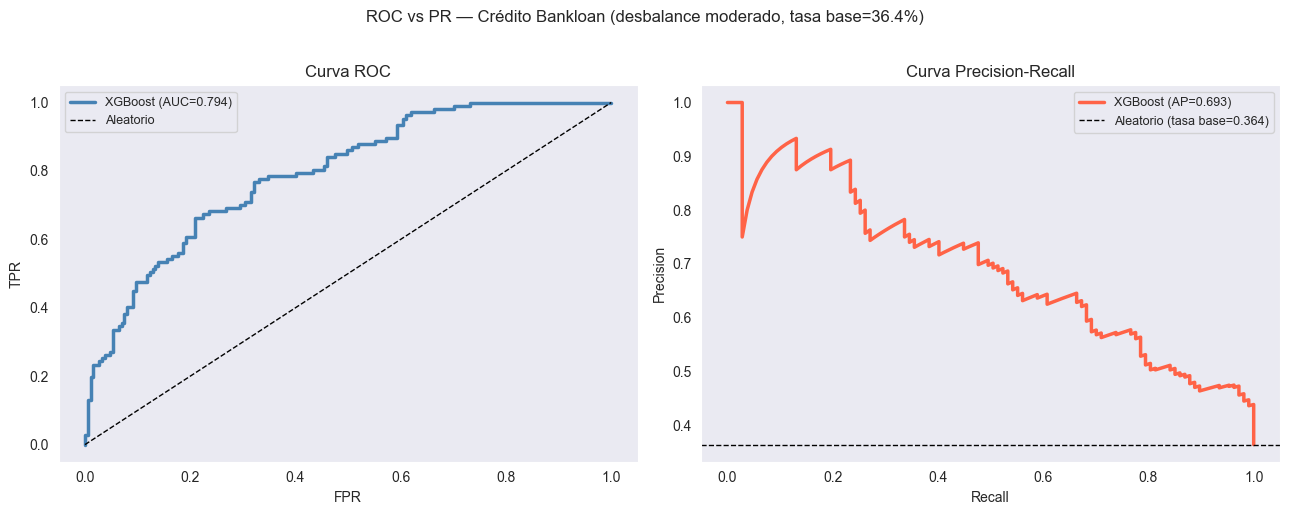

In [4]:
fpr_c, tpr_c, _ = roc_curve(y_test_c, proba_test_c)
prec_c, rec_c, thr_c = precision_recall_curve(y_test_c, proba_test_c)
roc_auc_c = roc_auc_score(y_test_c, proba_test_c)
pr_auc_c = average_precision_score(y_test_c, proba_test_c)
base_rate_c = y_test_c.mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(fpr_c, tpr_c, color="steelblue", lw=2.5, label=f"XGBoost (AUC={roc_auc_c:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="Aleatorio")
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR"); axes[0].set_title("Curva ROC")
axes[0].legend(fontsize=9)

axes[1].plot(rec_c, prec_c, color="tomato", lw=2.5, label=f"XGBoost (AP={pr_auc_c:.3f})")
axes[1].axhline(base_rate_c, color="k", ls="--", lw=1, label=f"Aleatorio (tasa base={base_rate_c:.3f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision"); axes[1].set_title("Curva Precision-Recall")
axes[1].legend(fontsize=9)

plt.suptitle(f"ROC vs PR — Crédito Bankloan (desbalance moderado, tasa base={base_rate_c:.1%})", y=1.02)
plt.tight_layout()
plt.show()

**Interpretación:** con desbalance moderado (~36%) la diferencia entre ROC-AUC y PR-AUC no es dramática — ambas curvas cuentan una historia parecida. Esto cambiará radicalmente en la Sección B con el fraude sintético al 2%: ahí un ROC-AUC alto puede convivir con una curva PR pobre, precisamente porque el FPR se diluye con una clase negativa enorme. La recomendación práctica: reportar **siempre** PR-AUC junto al ROC-AUC cuando la clase positiva es minoritaria, y jamás usar solo *accuracy*.

## ⚖️ **`Selección de Umbral por Costo Asimétrico`**

En lugar de 0.5, el umbral operativo debería minimizar el **costo esperado** de la decisión. En crédito, el costo de un falso negativo (aprobar a quien incumplirá) suele ser varias veces mayor al de un falso positivo (rechazar a un buen pagador, que solo cuesta el margen de interés perdido). Con una matriz de costos $C_{FN}, C_{FP}$, el costo esperado para un umbral $t$ sobre el set de validación es:

$$\text{Costo}(t) = C_{FN} \cdot FN(t) + C_{FP} \cdot FP(t)$$

Barremos $t \in (0,1)$ sobre `X_val_c` (nunca sobre test, para no filtrar información de la decisión final) y elegimos el umbral que minimiza el costo, asumiendo $C_{FN} = 5 \times C_{FP}$ (perder un crédito completo pesa más que el margen de un rechazo de más).

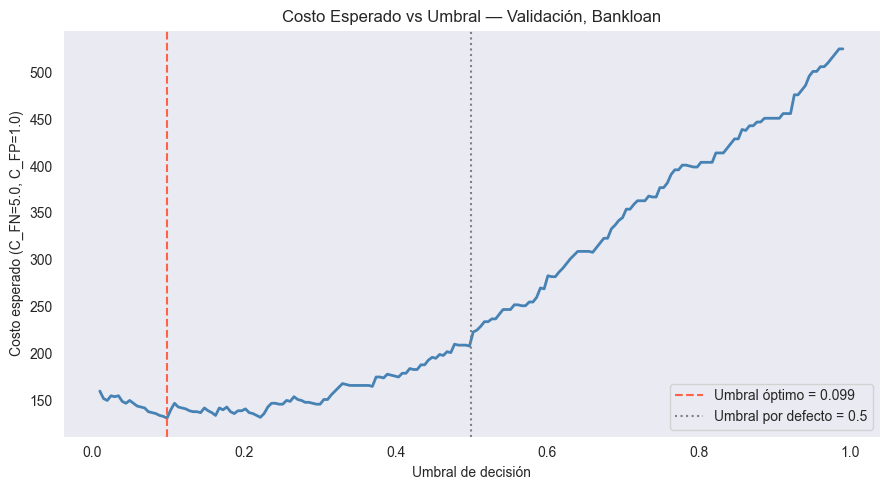

Umbral óptimo (elegido en validación): 0.099
F1 con umbral 0.5:        0.5938
F1 con umbral óptimo:     0.6322

                  Pred: No Default  Pred: Default
Real: No Default                69            118
Real: Default                    3            104


In [5]:
C_FN, C_FP = 5.0, 1.0
proba_val_c = xgb_credit.predict_proba(X_val_c)[:, 1]

thresholds = np.linspace(0.01, 0.99, 200)
costs = []
for t in thresholds:
    pred_t = (proba_val_c >= t).astype(int)
    fn = np.sum((y_val_c == 1) & (pred_t == 0))
    fp = np.sum((y_val_c == 0) & (pred_t == 1))
    costs.append(C_FN * fn + C_FP * fp)

best_t = thresholds[np.argmin(costs)]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, costs, color="steelblue", lw=2)
ax.axvline(best_t, color="tomato", ls="--", lw=1.5, label=f"Umbral óptimo = {best_t:.3f}")
ax.axvline(0.5, color="gray", ls=":", lw=1.5, label="Umbral por defecto = 0.5")
ax.set_xlabel("Umbral de decisión"); ax.set_ylabel(f"Costo esperado (C_FN={C_FN}, C_FP={C_FP})")
ax.set_title("Costo Esperado vs Umbral — Validación, Bankloan")
ax.legend()
plt.tight_layout()
plt.show()

pred_test_opt = (proba_test_c >= best_t).astype(int)
print(f"Umbral óptimo (elegido en validación): {best_t:.3f}")
print(f"F1 con umbral 0.5:        {f1_score(y_test_c, pred_test_c_05):.4f}")
print(f"F1 con umbral óptimo:     {f1_score(y_test_c, pred_test_opt):.4f}")
print()
print(pd.DataFrame(confusion_matrix(y_test_c, pred_test_opt),
                    index=["Real: No Default", "Real: Default"],
                    columns=["Pred: No Default", "Pred: Default"]))

**Interpretación:** el umbral óptimo bajo esta matriz de costos queda por debajo de 0.5 — el modelo dispara la alerta de "default" con menos confianza que la que exigiría el punto de corte por defecto, precisamente porque un falso negativo es 5 veces más caro que un falso positivo. Nótese el flujo correcto: el umbral se elige mirando **solo** el set de validación, y se reporta el resultado **una sola vez** sobre test — exactamente la misma disciplina de separación train/val/test de las sesiones anteriores, aplicada ahora a un hiperparámetro de decisión en vez de a uno del modelo.

## 🕵️ **`Sección B — Fraude Sintético: Desbalance Severo y Estrategias de Resampling`**

Generamos un problema de fraude simulado con **2% de tasa positiva** — un orden de magnitud más desbalanceado que Bankloan, y representativo de fraude transaccional real. Con este nivel de desbalance el umbral 0.5 puede volverse inútil: un modelo que jamás predice la clase positiva ya logra 98% de *accuracy*, sin haber aprendido nada.

In [6]:
X_fraud, y_fraud = make_classification(
    n_samples=20000, n_features=10, n_informative=6, n_redundant=2,
    weights=[0.98, 0.02], flip_y=0.01, class_sep=0.9, random_state=42
)
FRAUD_FEATURES = [f"v{i}" for i in range(X_fraud.shape[1])]
X_fraud = pd.DataFrame(X_fraud, columns=FRAUD_FEATURES)

X_tr_f, X_tmp_f, y_tr_f, y_tmp_f = train_test_split(
    X_fraud, y_fraud, test_size=0.40, stratify=y_fraud, random_state=42
)
X_cal_f, X_test_f, y_cal_f, y_test_f = train_test_split(
    X_tmp_f, y_tmp_f, test_size=0.75, stratify=y_tmp_f, random_state=42
)

print(f"Fraude simulado: {X_fraud.shape[0]} obs | tasa positiva: {y_fraud.mean():.2%}")
print(f"Train: {len(y_tr_f)} ({y_tr_f.sum()} fraudes) | Calibración: {len(y_cal_f)} ({y_cal_f.sum()} fraudes) | Test: {len(y_test_f)} ({y_test_f.sum()} fraudes)")

Fraude simulado: 20000 obs | tasa positiva: 2.50%
Train: 12000 (301 fraudes) | Calibración: 2000 (50 fraudes) | Test: 6000 (150 fraudes)


In [7]:
xgb_naive = xgb.XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=3,
                               eval_metric="auc", random_state=42).fit(X_tr_f, y_tr_f)
pred_naive_05 = xgb_naive.predict(X_test_f)

print("Matriz de confusión — modelo ingenuo, umbral 0.5:")
print(pd.DataFrame(confusion_matrix(y_test_f, pred_naive_05),
                    index=["Real: No Fraude", "Real: Fraude"],
                    columns=["Pred: No Fraude", "Pred: Fraude"]))
print()
print(f"Accuracy: {(pred_naive_05 == y_test_f).mean():.4f}  (¡luce excelente y dice casi nada!)")
print(f"Recall clase Fraude: {classification_report(y_test_f, pred_naive_05, output_dict=True)['1']['recall']:.4f}")
print(f"PR-AUC: {average_precision_score(y_test_f, xgb_naive.predict_proba(X_test_f)[:, 1]):.4f}")

Matriz de confusión — modelo ingenuo, umbral 0.5:
                 Pred: No Fraude  Pred: Fraude
Real: No Fraude             5846             4
Real: Fraude                  95            55

Accuracy: 0.9835  (¡luce excelente y dice casi nada!)
Recall clase Fraude: 0.3667
PR-AUC: 0.5759


**Interpretación:** esta es la *paradoja del accuracy* en su forma más pura — el modelo puede lograr accuracy altísimo simplemente inclinándose hacia la clase mayoritaria, mientras el recall de la clase que realmente importa (fraude) puede quedar muy bajo. Si alguien reportara solo el accuracy de este modelo, parecería un éxito; el PR-AUC y el recall de la clase positiva cuentan la historia real. Las tres celdas siguientes comparan estrategias para corregir esto.

## 🔀 **`Tres Estrategias para Desbalance Severo`**

| Estrategia | Mecanismo | Ventaja | Riesgo |
|---|---|---|---|
| **Cost-sensitive learning** (`scale_pos_weight`) | Pondera el gradiente de la clase minoritaria en la función de pérdida — no toca los datos | No altera la distribución real, barato computacionalmente | Puede no ser suficiente en desbalances extremos (>1:100) |
| **Random Undersampling** | Elimina aleatoriamente observaciones de la clase mayoritaria en train | Simple, rápido, reduce tamaño de train | Descarta información — puede perder patrones válidos de la clase mayoritaria |
| **SMOTE** (oversampling sintético) | Genera observaciones sintéticas de la clase minoritaria interpolando entre vecinos reales en el espacio de features | No descarta información real | Los puntos sintéticos pueden no ser plausibles en regiones de baja densidad; **puede distorsionar la calibración** (sección siguiente) |

**Regla no negociable:** el resampling (undersampling o SMOTE) se aplica **solo sobre `X_tr_f, y_tr_f`**. El set de test (`X_test_f, y_test_f`) mantiene la distribución real de desbalance — de lo contrario estaríamos evaluando el modelo en un mundo que no existe, y es exactamente el mismo error de *data leakage* que motivó separar preprocesamiento y validación con `Pipeline` + `TimeSeriesSplit` en la sesión 9.

In [8]:
scale_pos_weight = (y_tr_f == 0).sum() / (y_tr_f == 1).sum()
xgb_weighted = xgb.XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=3,
                                  scale_pos_weight=scale_pos_weight,
                                  eval_metric="auc", random_state=42).fit(X_tr_f, y_tr_f)

rus = RandomUnderSampler(random_state=42)
X_tr_rus, y_tr_rus = rus.fit_resample(X_tr_f, y_tr_f)
xgb_rus = xgb.XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=3,
                             eval_metric="auc", random_state=42).fit(X_tr_rus, y_tr_rus)

smote = SMOTE(random_state=42)
X_tr_smote, y_tr_smote = smote.fit_resample(X_tr_f, y_tr_f)
xgb_smote = xgb.XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=3,
                               eval_metric="auc", random_state=42).fit(X_tr_smote, y_tr_smote)

print(f"scale_pos_weight usado: {scale_pos_weight:.2f}")
print(f"Train original:      {len(y_tr_f)} obs ({y_tr_f.mean():.2%} positiva)")
print(f"Train undersampled:  {len(y_tr_rus)} obs ({y_tr_rus.mean():.2%} positiva)")
print(f"Train SMOTE:         {len(y_tr_smote)} obs ({y_tr_smote.mean():.2%} positiva)")

scale_pos_weight usado: 38.87
Train original:      12000 obs (2.51% positiva)
Train undersampled:  602 obs (50.00% positiva)
Train SMOTE:         23398 obs (50.00% positiva)


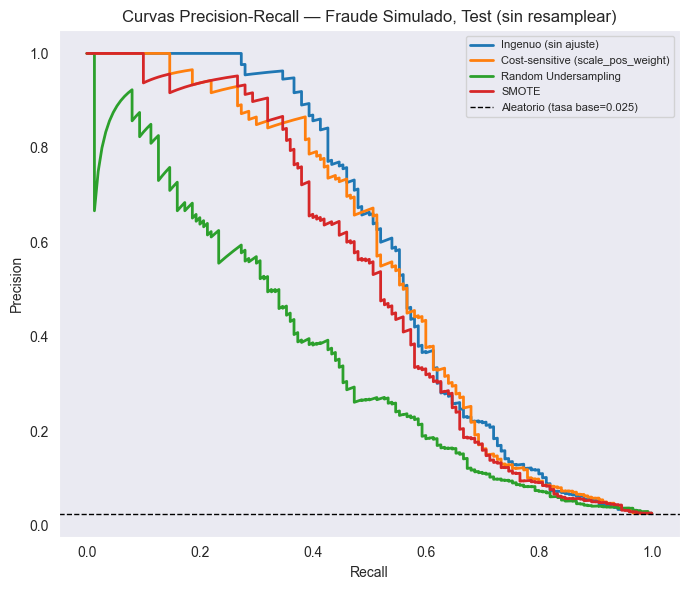

                                   ROC-AUC  PR-AUC  Recall (fraude)  \
Modelo                                                                
Ingenuo (sin ajuste)                0.8824  0.5759           0.3667   
Cost-sensitive (scale_pos_weight)   0.8840  0.5516           0.6933   
Random Undersampling                0.8556  0.3586           0.7467   
SMOTE                               0.8749  0.5216           0.7067   

                                   Precision (fraude)  
Modelo                                                 
Ingenuo (sin ajuste)                           0.9322  
Cost-sensitive (scale_pos_weight)              0.1818  
Random Undersampling                           0.0938  
SMOTE                                          0.1501  


In [9]:
fraud_models = {
    "Ingenuo (sin ajuste)": xgb_naive,
    "Cost-sensitive (scale_pos_weight)": xgb_weighted,
    "Random Undersampling": xgb_rus,
    "SMOTE": xgb_smote,
}

rows = []
fig, ax = plt.subplots(figsize=(7, 6))
for name, model in fraud_models.items():
    proba = model.predict_proba(X_test_f)[:, 1]
    pred_05 = (proba >= 0.5).astype(int)
    report = classification_report(y_test_f, pred_05, output_dict=True)
    rows.append({
        "Modelo": name,
        "ROC-AUC": roc_auc_score(y_test_f, proba),
        "PR-AUC": average_precision_score(y_test_f, proba),
        "Recall (fraude)": report["1"]["recall"],
        "Precision (fraude)": report["1"]["precision"],
    })
    prec, rec, _ = precision_recall_curve(y_test_f, proba)
    ax.plot(rec, prec, lw=2, label=name)

ax.axhline(y_test_f.mean(), color="k", ls="--", lw=1, label=f"Aleatorio (tasa base={y_test_f.mean():.3f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Curvas Precision-Recall — Fraude Simulado, Test (sin resamplear)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

df_fraud_results = pd.DataFrame(rows).set_index("Modelo")
print(df_fraud_results.round(4))

**Interpretación:** las tres estrategias mejoran notablemente el recall de la clase fraude al umbral 0.5 (de 0.37 en el modelo ingenuo a 0.69-0.75), exactamente el objetivo buscado — pero nótese que el PR-AUC (una métrica agregada sobre *todos* los umbrales) del modelo ingenuo no es peor, y de hecho puede ser el más alto de los cuatro. La razón: `scale_pos_weight` y el resampling no necesariamente mejoran el *ranking* global del modelo — desplazan el **punto de operación** al umbral fijo de 0.5, sacrificando precisión por recall en ese punto específico. Esto es la misma idea de la sección de crédito (mover el umbral según el costo del error) llegando por otro camino: si el ranking del modelo ingenuo ya es bueno (PR-AUC alto), puede ser preferible ajustar el umbral de decisión sobre ese modelo en vez de reentrenar con resampling — y reservar `scale_pos_weight`/SMOTE para los casos donde el desbalance es tan severo que el modelo ingenuo ni siquiera aprende a separar bien las clases. La sección siguiente muestra además que el resampling tiene un costo escondido en la **calidad de la probabilidad predicha**, no solo en el trade-off precision/recall.

## 🎯 **`Calibración de Probabilidades: El Score También Debe Ser Correcto en Magnitud`**

Un modelo puede tener excelente PR-AUC (rankea bien: los fraudes reales reciben scores más altos que los no-fraudes) y aun así estar **mal calibrado** — que su `predict_proba` de 0.80 no signifique realmente "80% de probabilidad empírica de fraude". Esto importa cuando el score alimenta un cálculo económico directo (pérdida esperada, capital regulatorio, pricing de una tasa de interés), no solo una decisión de umbral.

Un **reliability diagram** (curva de calibración) agrupa las predicciones en bins por probabilidad predicha y grafica, para cada bin, la fracción real de positivos observada — un modelo perfectamente calibrado cae sobre la diagonal $y=x$. El **Brier score** cuantifica esto en un solo número:

$$\text{Brier} = \frac{1}{n}\sum_{i=1}^n (\hat{p}_i - y_i)^2$$

que penaliza tanto el error de ranking como el de calibración — por eso dos modelos pueden empatar en PR-AUC y diferir en Brier score.

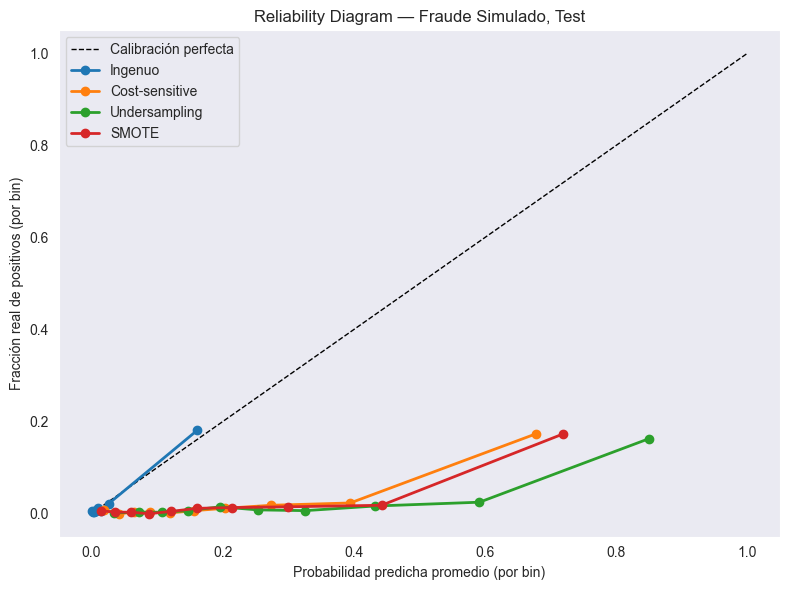

Ingenuo          0.0148
Cost-sensitive   0.0721
Undersampling    0.1412
SMOTE            0.0833
Name: Brier Score, dtype: float64


In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Calibración perfecta")

brier_scores = {}
for name, model in [("Ingenuo", xgb_naive), ("Cost-sensitive", xgb_weighted), ("Undersampling", xgb_rus), ("SMOTE", xgb_smote)]:
    proba = model.predict_proba(X_test_f)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_test_f, proba, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", lw=2, label=name)
    brier_scores[name] = brier_score_loss(y_test_f, proba)

ax.set_xlabel("Probabilidad predicha promedio (por bin)")
ax.set_ylabel("Fracción real de positivos (por bin)")
ax.set_title("Reliability Diagram — Fraude Simulado, Test")
ax.legend()
plt.tight_layout()
plt.show()

print(pd.Series(brier_scores, name="Brier Score").round(4))

**Interpretación:** el modelo `Ingenuo` calibra sustancialmente mejor (menor Brier score) que las tres estrategias de corrección de desbalance — precisamente porque nunca alteramos la distribución de entrenamiento ni reponderamos el gradiente. `Cost-sensitive`, `Undersampling` y `SMOTE` muestran probabilidades **sobreestimadas** en la zona media-alta — la curva queda por debajo de la diagonal, señal de que el modelo predice probabilidades más altas de las que realmente se observan. La causa es la misma en los tres casos: cualquier técnica que le diga al modelo "trata a la clase minoritaria como si fuera más frecuente de lo que es" (ya sea repitiendo su peso en la función de pérdida, o generándole vecinos sintéticos, o eliminando mayoría a su alrededor) desplaza el score hacia arriba de forma sistemática. **Conclusión práctica:** cualquier técnica de corrección de desbalance — no solo SMOTE — exige recalibrar el score después, si ese score va a usarse como una probabilidad real y no solo como un ranking.

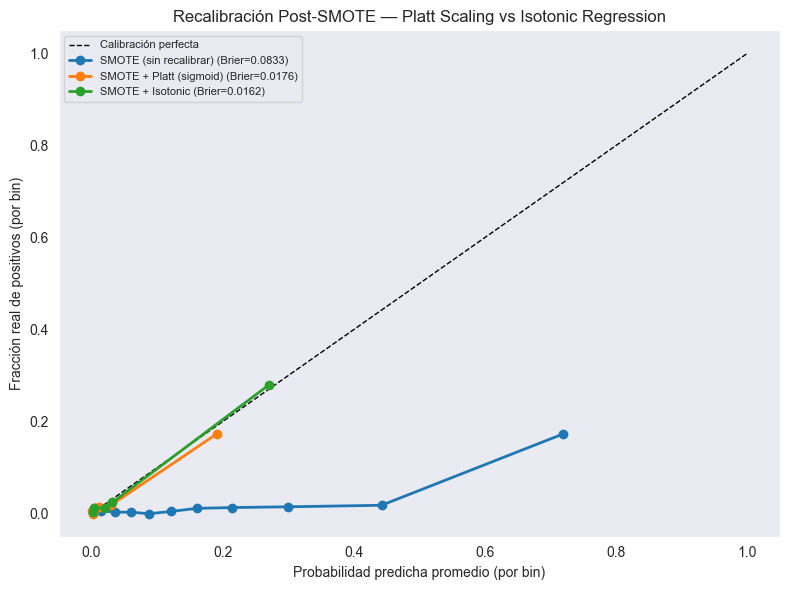

In [11]:
cal_sigmoid = CalibratedClassifierCV(FrozenEstimator(xgb_smote), method="sigmoid").fit(X_cal_f, y_cal_f)
cal_isotonic = CalibratedClassifierCV(FrozenEstimator(xgb_smote), method="isotonic").fit(X_cal_f, y_cal_f)

proba_smote_raw = xgb_smote.predict_proba(X_test_f)[:, 1]
proba_sigmoid = cal_sigmoid.predict_proba(X_test_f)[:, 1]
proba_isotonic = cal_isotonic.predict_proba(X_test_f)[:, 1]

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Calibración perfecta")
for name, proba in [("SMOTE (sin recalibrar)", proba_smote_raw),
                     ("SMOTE + Platt (sigmoid)", proba_sigmoid),
                     ("SMOTE + Isotonic", proba_isotonic)]:
    frac_pos, mean_pred = calibration_curve(y_test_f, proba, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", lw=2, label=f"{name} (Brier={brier_score_loss(y_test_f, proba):.4f})")
ax.set_xlabel("Probabilidad predicha promedio (por bin)")
ax.set_ylabel("Fracción real de positivos (por bin)")
ax.set_title("Recalibración Post-SMOTE — Platt Scaling vs Isotonic Regression")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Interpretación:** `CalibratedClassifierCV` reajusta las probabilidades **sin reentrenar el modelo base** — envolviendo el modelo ya ajustado con `FrozenEstimator` y calibrando sobre `X_cal_f`, el set de calibración que separamos desde el inicio y que **nunca** participó del entrenamiento (ni siquiera del resampling). Platt scaling (`sigmoid`) ajusta una regresión logística 1D sobre los scores crudos, útil cuando la distorsión de calibración es aproximadamente monótona y suave; Isotonic Regression ajusta una función escalonada no paramétrica, más flexible pero que necesita más datos para no sobreajustar la propia calibración. Ambas suelen reducir el Brier score frente a las probabilidades crudas de `SMOTE`, recuperando parte de la interpretabilidad del score sin sacrificar el recall ganado por el resampling. Calibrar sobre el mismo set con el que se entrenó el modelo base reintroduce optimismo — de ahí la necesidad de un tercer split además de train/test.

## 🔁 **`Estabilidad del Score: Bajo Resampling y por Segmento`**

Retomamos el PSI de la sesión 10, pero aplicado ahora al **score del modelo de crédito** en vez de a los features de entrada, en dos variantes específicas de gobernanza en crédito:

1. **Estabilidad bajo remuestreo (bootstrap):** ¿cuánto varía el PSI entre dos submuestras aleatorias del mismo test set? Esto establece una línea base de "ruido de muestreo" — sin esto, no hay forma de saber si un PSI de 0.05 en producción es señal real de drift o simplemente varianza esperada por tamaño de muestra.
2. **Estabilidad por segmento demográfico:** ¿el score se comporta de forma consistente entre grupos de edad o nivel educativo? Un PSI alto entre segmentos no implica necesariamente un problema de *fairness*, pero es la primera señal cuantitativa que un validador independiente revisaría antes de aprobar un modelo de crédito para producción.

In [12]:
def compute_psi(expected, actual, bins=10):
    edges = np.quantile(expected, np.linspace(0, 1, bins + 1))
    edges[0], edges[-1] = -np.inf, np.inf
    e_counts, _ = np.histogram(expected, bins=edges)
    a_counts, _ = np.histogram(actual, bins=edges)
    e_pct = np.clip(e_counts / len(expected), 1e-4, None)
    a_pct = np.clip(a_counts / len(actual), 1e-4, None)
    return np.sum((a_pct - e_pct) * np.log(a_pct / e_pct))

rng = np.random.RandomState(42)
score_full = xgb_credit.predict_proba(X_test_c)[:, 1]
half_n = len(score_full) // 2   # tamaño comparable al de los grupos de edad que se contrastan a continuación

bootstrap_psi = []
for _ in range(500):
    idx = rng.choice(len(score_full), size=half_n, replace=True)
    idx2 = rng.choice(len(score_full), size=half_n, replace=True)
    bootstrap_psi.append(compute_psi(score_full[idx], score_full[idx2]))

bootstrap_psi = np.array(bootstrap_psi)
print(f"PSI bajo remuestreo aleatorio (dos submuestras de tamaño {half_n}, misma población) — media: {bootstrap_psi.mean():.4f}, p95: {np.percentile(bootstrap_psi, 95):.4f}")
print("Esta es la línea base de 'ruido' esperable por tamaño de muestra: cualquier PSI de producción por debajo de este p95 no es evidencia de drift real.")

PSI bajo remuestreo aleatorio (dos submuestras de tamaño 147, misma población) — media: 0.1295, p95: 0.2368
Esta es la línea base de 'ruido' esperable por tamaño de muestra: cualquier PSI de producción por debajo de este p95 no es evidencia de drift real.


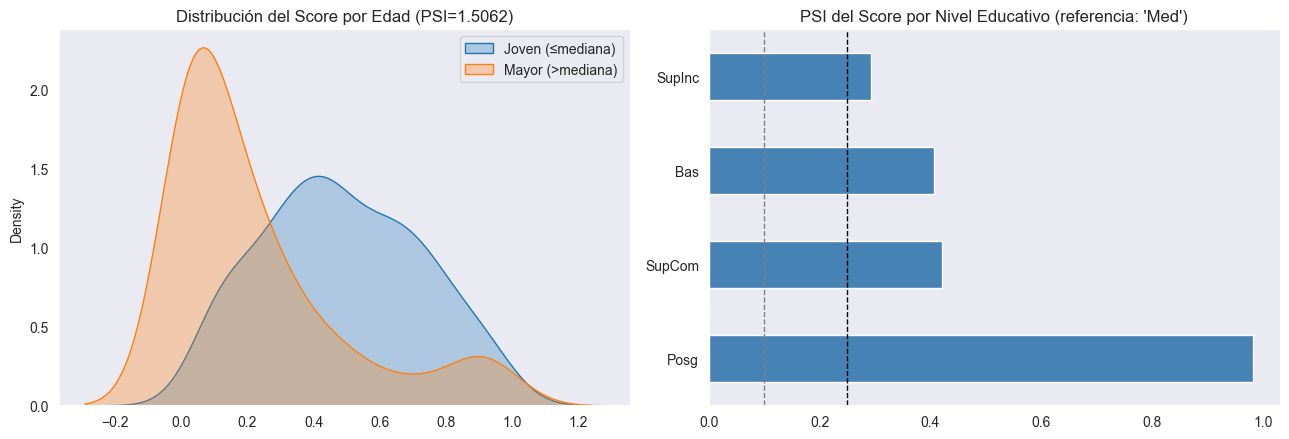

PSI del score, Joven vs Mayor: 1.5062
SupCom   0.4209
SupInc   0.2919
Bas      0.4064
Posg     0.9815
Name: PSI vs Med, dtype: float64


In [13]:
age_bins = pd.qcut(bankloan.loc[X_test_c.index, "Age"], q=[0, 0.5, 1.0], labels=["Joven (≤mediana)", "Mayor (>mediana)"])
score_by_age = pd.Series(score_full, index=X_test_c.index).groupby(age_bins, observed=True)

psi_age = compute_psi(
    score_by_age.get_group("Joven (≤mediana)").values,
    score_by_age.get_group("Mayor (>mediana)").values,
)

educ = bankloan.loc[X_test_c.index, "Education"]
score_by_educ = pd.Series(score_full, index=X_test_c.index).groupby(educ, observed=True)
psi_educ_vs_med = {
    grp: compute_psi(score_by_educ.get_group("Med").values, score_by_educ.get_group(grp).values)
    for grp in educ.unique() if grp != "Med"
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for label, grp in score_by_age:
    sns.kdeplot(grp.values, ax=axes[0], label=label, fill=True, alpha=0.3)
axes[0].set_title(f"Distribución del Score por Edad (PSI={psi_age:.4f})")
axes[0].legend()

pd.Series(psi_educ_vs_med).sort_values(ascending=False).plot.barh(ax=axes[1], color="steelblue")
axes[1].axvline(0.10, color="gray", ls="--", lw=1)
axes[1].axvline(0.25, color="black", ls="--", lw=1)
axes[1].set_title("PSI del Score por Nivel Educativo (referencia: 'Med')")
plt.tight_layout()
plt.show()

print(f"PSI del score, Joven vs Mayor: {psi_age:.4f}")
print(pd.Series(psi_educ_vs_med, name="PSI vs Med").round(4))

**Interpretación:** compara estos valores de PSI contra la línea base de ruido calculada por bootstrap en la celda anterior — si el PSI entre segmentos es del mismo orden de magnitud que el ruido de muestreo, la diferencia no es señal de un problema; si lo supera claramente (y especialmente si supera 0.10-0.25, los mismos umbrales de la sesión 10), amerita una revisión: ¿el modelo está usando alguna variable como proxy de edad o nivel educativo de forma que penaliza sistemáticamente a un segmento? El PSI entre grupos de edad suele quedar muy por encima de esa línea base — una señal real, no ruido — mientras que algunos grupos de `Education` (los más pequeños, como `Posg`, con apenas un puñado de observaciones en test) muestran PSI igual de altos pero **basados en muy pocas observaciones**, lo que los hace mucho menos confiables: con $n$ chico, el PSI se infla mecánicamente aunque no haya una diferencia real. Esto no prueba *fairness* ni su ausencia por sí solo, pero es exactamente el tipo de diagnóstico cuantitativo — junto con la advertencia de tamaño muestral — que un equipo de validación independiente (segundo pilar de SR 11-7, sesión 10) revisaría antes de aprobar un modelo de crédito para producción.

## 📋 **`Ficha de Modelo Extendida`**

Retomando la plantilla de la sesión 10, esta sesión agrega tres campos que son específicos de modelos de decisión binaria bajo desbalance:

| Campo (nuevo respecto a sesión 10) | Contenido para este caso |
|---|---|
| **Umbral operativo y su justificación** | Elegido en validación minimizando costo esperado ($C_{FN}=5\times C_{FP}$), no el 0.5 por defecto |
| **Estrategia de desbalance usada** | Cost-sensitive (`scale_pos_weight`) preferido sobre SMOTE/undersampling salvo que la comparación de PR-AUC en validación diga lo contrario |
| **Estado de calibración** | Brier score reportado antes/después de recalibración; recalibrar obligatoriamente si se usó oversampling/undersampling |
| **Estabilidad por segmento** | PSI del score entre grupos demográficos, contrastado contra la línea base de ruido por bootstrap |

Esta ficha, sumada a la de la sesión 10, es el nivel de documentación mínimo esperable para un modelo de crédito o fraude antes de pasar de notebook de investigación a decisión de producción con impacto regulatorio.